# Human Development Index (HDI) Prediction - Exploratory Data Analysis & Modeling

This notebook demonstrates the end-to-end Machine Learning pipeline to predict the **Human Development Index (HDI) Score** of countries based on three key indicators:
1. **Life Expectancy**
2. **Mean Years of Schooling**
3. **Gross National Income (GNI) Per Capita**

### Tech Stack:
- **Data Manipulation**: NumPy, Pandas
- **Data Visualization**: Matplotlib, Seaborn
- **Machine Learning**: Scikit-learn (Linear Regression)
- **Serialization**: Pickle

## 1. Imports
We import the required libraries for scientific computing, visual analysis, regression modeling, and model export.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import pickle
import os

# Set plotting style
sns.set_theme(style="whitegrid")
print("Libraries successfully imported!")

## 2. Dataset Loading and Initial Analysis
We load the representative real-world UNDP dataset compiled inside `../dataset/hdi_data.csv`.

In [2]:
# Load dataset
df = pd.read_csv('../dataset/hdi_data.csv')

print(f"Dataset Shape: {df.shape}\n")
print("--- First 5 Rows ---")
display(df.head())

print("\n--- Dataset Info ---")
df.info()

print("\n--- Missing Value Counts ---")
print(df.isnull().sum())

Dataset Shape: (150, 5)

--- First 5 Rows ---


,Country Name,Life Expectancy,Mean Years of Schooling,GNI Per Capita,HDI Score
0,Norway,83.2,13.0,66000.0,0.961
1,Switzerland,84.0,13.9,69000.0,0.962
2,Ireland,82.8,12.7,76000.0,0.955
3,Germany,81.3,14.1,55000.0,0.942
4,Sweden,83.5,12.6,54000.0,0.945



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country Name             150 non-null    object 
 1   Life Expectancy          149 non-null    float64
 2   Mean Years of Schooling  149 non-null    float64
 3   GNI Per Capita           149 non-null    float64
 4   HDI Score                150 non-null    float64
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

--- Missing Value Counts ---
Country Name               0
Life Expectancy            1
Mean Years of Schooling    1
GNI Per Capita             1
HDI Score                  0
dtype: int64


--- Describe Dataset Statistics ---

In [3]:
df.describe()

,Life Expectancy,Mean Years of Schooling,GNI Per Capita,HDI Score
count,149.000000,149.000000,149.000000,150.000000
mean,73.744295,9.652349,23141.275168,0.764953
std,6.774788,2.682541,20305.226437,0.121884
min,52.700000,4.300000,2100.000000,0.525000
25%,70.100000,7.400000,7500.000000,0.683500
50%,74.000000,10.400000,14000.000000,0.770500
75%,78.700000,11.900000,36000.000000,0.862250
max,85.500000,14.100000,90000.000000,0.962000


## 3. Exploratory Data Analysis (EDA)
We generate standard plots to explore feature distributions, class separations, and correlations.

### A. Strip Plot: HDI Score grouped by Human Development Level
We group the scores into low (<0.550), medium (0.550-0.700), high (0.700-0.800), and very high (>=0.800) to see visual distribution.

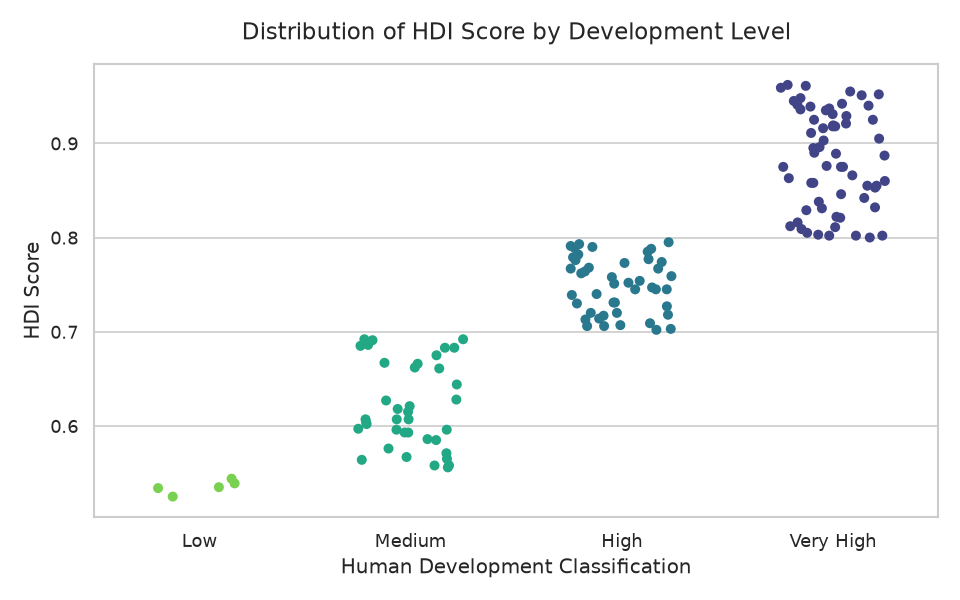

In [4]:
# Preprocess categories temporarily for plotting
def get_group(score):
    if score < 0.550: return 'Low'
    elif score < 0.700: return 'Medium'
    elif score < 0.800: return 'High'
    else: return 'Very High'

df_plot = df.copy()
df_plot['HDI Group'] = df_plot['HDI Score'].apply(get_group)

plt.figure(figsize=(8, 5))
sns.stripplot(x='HDI Group', y='HDI Score', data=df_plot, order=['Low', 'Medium', 'High', 'Very High'], palette='viridis', hue='HDI Group', size=6, jitter=0.25)
plt.title('Distribution of HDI Score by Development Level', fontsize=14, pad=15)
plt.xlabel('Human Development Classification', fontsize=12)
plt.ylabel('HDI Score', fontsize=12)
plt.tight_layout()
plt.show()

### B. Distribution Plot: Kernel Density Estimate (KDE) of HDI Score
Visualizing the overall distribution profile of the target variable.

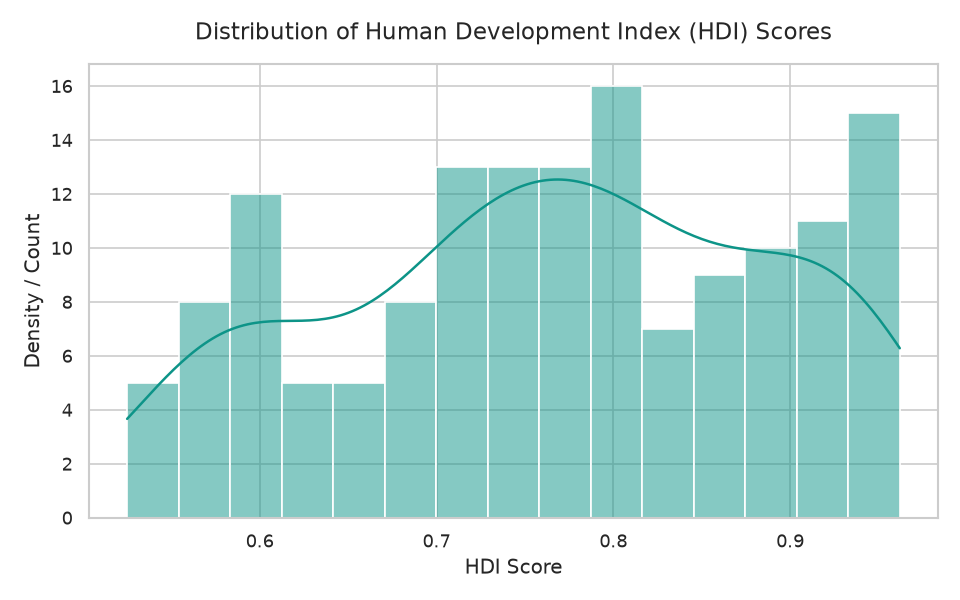

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df['HDI Score'], kde=True, color='#0d9488', bins=15)
plt.title('Distribution of Human Development Index (HDI) Scores', fontsize=14, pad=15)
plt.xlabel('HDI Score', fontsize=12)
plt.ylabel('Density / Count', fontsize=12)
plt.tight_layout()
plt.show()

### C. Scatter Plots: Relationship of Features vs HDI Score
Analyzing relationships between individual predictors and the target variable.

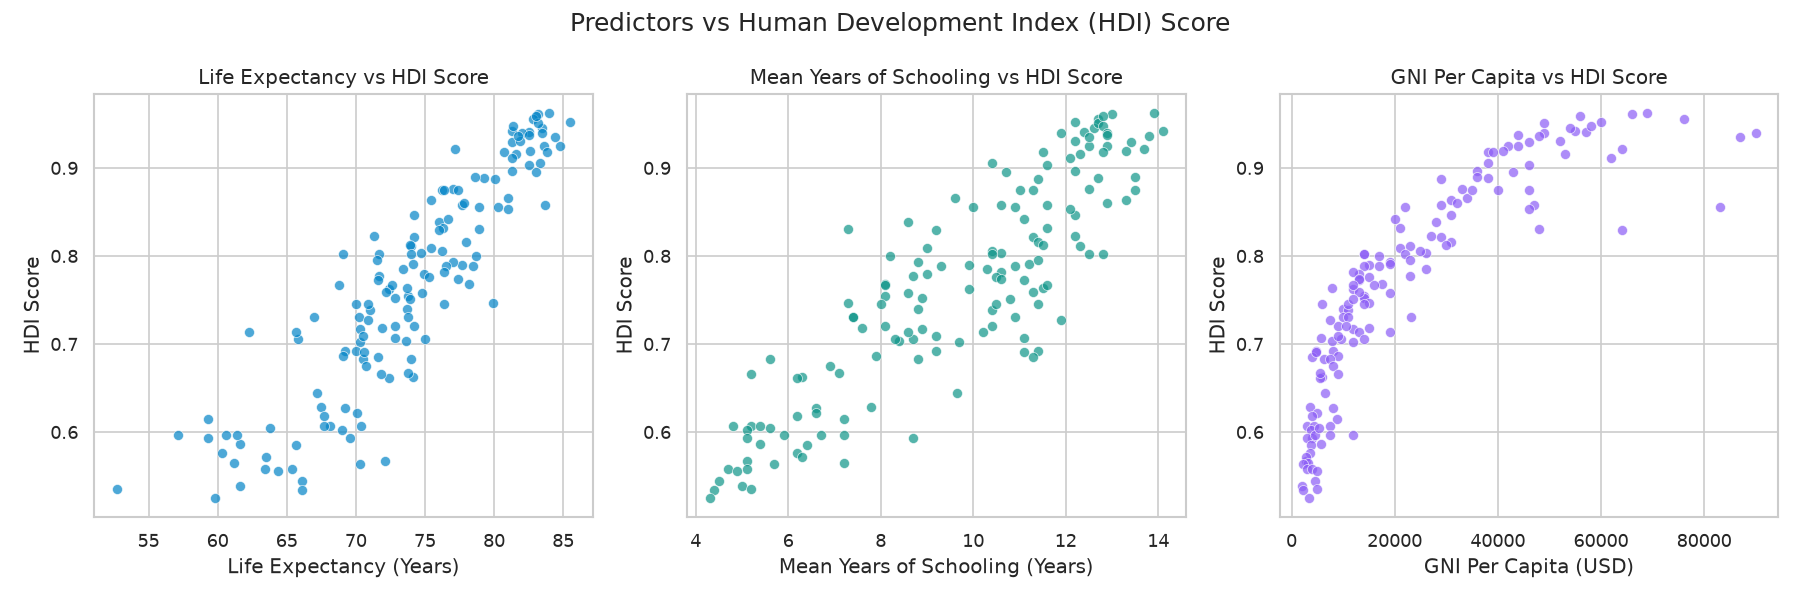

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Life Expectancy
sns.scatterplot(ax=axes[0], x='Life Expectancy', y='HDI Score', data=df, color='#0284c7', alpha=0.7)
axes[0].set_title('Life Expectancy vs HDI Score', fontsize=12)
axes[0].set_xlabel('Life Expectancy (Years)')
axes[0].set_ylabel('HDI Score')

# Schooling
sns.scatterplot(ax=axes[1], x='Mean Years of Schooling', y='HDI Score', data=df, color='#0d9488', alpha=0.7)
axes[1].set_title('Mean Years of Schooling vs HDI Score', fontsize=12)
axes[1].set_xlabel('Mean Years of Schooling (Years)')
axes[1].set_ylabel('HDI Score')

# GNI
sns.scatterplot(ax=axes[2], x='GNI Per Capita', y='HDI Score', data=df, color='#8b5cf6', alpha=0.7)
axes[2].set_title('GNI Per Capita vs HDI Score', fontsize=12)
axes[2].set_xlabel('GNI Per Capita (USD)')
axes[2].set_ylabel('HDI Score')

plt.suptitle('Predictors vs Human Development Index (HDI) Score', fontsize=15, y=0.98)
plt.tight_layout()
plt.show()

### D. Heatmap & Correlation Matrix
Examining Pearson correlation coefficients between numerical features.

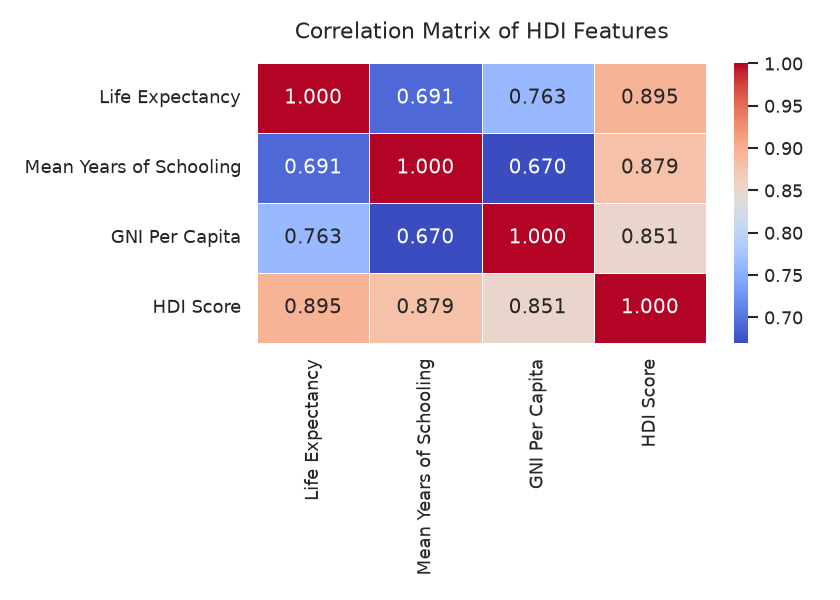

In [7]:
plt.figure(figsize=(7, 5))
numeric_cols = ['Life Expectancy', 'Mean Years of Schooling', 'GNI Per Capita', 'HDI Score']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Correlation Matrix of HDI Features', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing
We handle missing values by filling numeric null values with the mean of their respective columns.

In [8]:
print("Null counts before imputation:")
for col in ['Life Expectancy', 'Mean Years of Schooling', 'GNI Per Capita']:
    print(f"{col}: {df[col].isnull().sum()}")

# Imputation using mean
for col in ['Life Expectancy', 'Mean Years of Schooling', 'GNI Per Capita']:
    col_mean = df[col].mean()
    df[col] = df[col].fillna(col_mean)

print("\nNull counts after imputation:")
for col in ['Life Expectancy', 'Mean Years of Schooling', 'GNI Per Capita']:
    print(f"{col}: {df[col].isnull().sum()}")

Null counts before imputation:
Life Expectancy: 1
Mean Years of Schooling: 1
GNI Per Capita: 1

Null counts after imputation:
Life Expectancy: 0
Mean Years of Schooling: 0
GNI Per Capita: 0


### Splitting into Features and Target
- Independent Variables ($X$): `Life Expectancy`, `Mean Years of Schooling`, `GNI Per Capita`
- Dependent Variable ($y$): `HDI Score`
- Note: `Country Name` is dropped as it is a text identifier rather than a predictive feature.

In [9]:
X = df[['Life Expectancy', 'Mean Years of Schooling', 'GNI Per Capita']]
y = df['HDI Score']

print(f"Features Shape: {X.shape}")
print(f"Target Shape: {y.shape}")

# Train-test split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train Shape: {X_train.shape}, X_test Shape: {X_test.shape}")

Features Shape: (150, 3)
Target Shape: (150,)
X_train Shape: (120, 3), X_test Shape: (30, 3)


## 5. Model Training
We train a Linear Regression model. No feature scaling is performed to keep model coefficients and deployment inference direct and simple.

In [10]:
# Initialize and fit model
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression Model successfully trained!")
print(f"Intercept (Beta 0): {model.intercept_}")
print("Coefficients:")
for col, coef in zip(X.columns, model.coef_):
    print(f"  {col}: {coef:.8f}")

Linear Regression Model successfully trained!
Intercept (Beta 0): -0.04639912061952215
Coefficients:
  Life Expectancy: 0.00762696
  Mean Years of Schooling: 0.02450849
  GNI Per Capita: 0.00000216


## 6. Model Evaluation
We evaluate predictions on the test set using R² Score, Mean Squared Error (MSE), and Root Mean Squared Error (RMSE).

In [11]:
y_pred = model.predict(X_test)

r2 = metrics.r2_score(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("--- Evaluation Results ---")
print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")

--- Evaluation Results ---
R² Score: 0.9575
Mean Squared Error (MSE): 0.001150
Root Mean Squared Error (RMSE): 0.033909


## 7. Model Serialization
We save the trained model to `../model/hdi_model.pkl` using `pickle` so that it can be loaded for predictions in the Flask application.

In [12]:
# Export using pickle
model_export_path = '../model/hdi_model.pkl'
os.makedirs(os.path.dirname(model_export_path), exist_ok=True)
with open(model_export_path, 'wb') as f:
    pickle.dump(model, f)

print(f"Pickled model exported to {model_export_path} successfully!")

Pickled model exported to ../model/hdi_model.pkl successfully!
